# **Práctica 6 : Detección y comparación de huellas dactilares**
**Autores**: Luna Yue Hernández Guerra y Jorge Lorenzo Lorenzo

**Fecha**: Diciembre 2025

**Asignatura**: Procesamiento de Imágenes, Audio y Vídeo

---

## **Hipotésis clásica (sin IA)**
La primera hipótesis que planteamos es un sistema de verificación de huellas dactilares mediante un método clásico inspirado en el artículo de Park (2008) y con ciertas mejoras del análisis de Simón-Zorita (2003).

La idea se basa en realizar un **preprocesado** que incluye segmentación de la región de interés, ecualizado del histograma, un filtro bilateral, un realce de crestas con un operador Sobel y un refinamiento de la región de interés. Posteriormente, se tratará de utilizar **SIFT** para extraer y describir las características, que serán comparadas mediante la **distancia euclídea**. Tras calcular un índice de similitud se valorará si se acepta como genuino o se rechaza según un **umbral** definido.

El enfoque implementado cumple con los objetivos marcados en la hipótesis y el índice de similitud se evalúa con el *ratio* de inliers obtenidos.

#### **Referencias**
Park, U., Pankanti, S., & Jain, A. K. (2008, March). Fingerprint verification using SIFT features. In Biometric Technology for Human Identification V (Vol. 6944, pp. 166–174). SPIE.

Simón-Zorita, D., Ortega-García, J., Fierrez-Aguilar, J., & González-Rodríguez, J. (2003). Image quality and position variability assessment in minutiae-based fingerprint verification. IEE Proceedings – Vision, Image and Signal Processing, 150(6), 402–408.



## **Desarrollo**
**Librerías necesarias**

Se han utilizado las siguientes librerías:


In [1]:
from fileinput import filename
import os
import cv2 as cv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm
import json
import pandas as pd


### **Preprocesamiento de imágenes**
A continuación, se exponen los diferentes pasos del preprocesado de las imágenes llevados a cabo. Estos pasos son secuenciales, es decir, cada uno se aplica a los resultados del paso anterior. Los pasos son los siguientes:
1. Buscar y segmentar la ROI
2. Ecualizar y normalizar el histograma
3. Aplicar un filtro bilateral
4. Aplicar un realce de crestas
5. Refinar la ROI

#### **Buscar y segmentar la ROI**
El objetivo del primer paso del preprocesado es obtener el núcleo de la huella. Según el estudio de Simón-Zorita, este paso es realmente importante para conseguir un buen preprocesado de huellas.

Para ello, creamos dos funciones: `mejor_roi()` y `recortar_roi()`.
- `mejor_roi()`: Esta función obtiene la región de interés de una imagen. Dicha región de interés se define como la región de tamaño `ventana`x`ventana` donde más píxeles negros hay. Para ello, se recorre la imagen con un kernel de tamaño `ventana`x`ventana` dando pasos de `paso` píxeles y se obtiene la suma de píxeles negros. Una vez recorrida toda la imagen, se devuelven las coordenadas donde inicia la ventana y el ancho y alto de la misma, con lo que se pueden calcular las coordenadas de la región con mayor número de píxeles negros.
- `recortar_roi()`: Esta función guarda las regiones de interés de todas las imágenes que se encuentran en la ruta `db_path` en disco, en un directorio `out_path` especificado. Para ello, hace uso de la función `mejor_roi()` tras convertir las imágenes a escala de grises y binarizarlas usando `cv.THRESH_BINARY + cv.THRESH_OTSU`. La binarización combinada es sugerencia de ChatGPT para que el umbral se establezca dinámicamente.

Pedimos a Gemini y fragmento de código para aceptar tanto la estructura de 'data' como de 'test' y acelerar el procesamiento.

In [2]:
def mejor_roi(image, ventana=500, paso=20):
    """Encuentra la región de interés (ROI) en la imagen que contiene la mayor cantidad de píxeles negros."""

    H, W = image.shape
    w = min(ventana, W, H)
    h = min(ventana, W, H)
    mejor_ventana = (0, 0, w, h)
    mejor_suma = -1

    for y in range(0, H - h + 1, paso):
        for x in range(0, W - w + 1, paso):
            region = image[y:y+h, x:x+w]
            suma = np.sum(region == 0)

            if suma > mejor_suma:
                mejor_suma = suma
                mejor_ventana = (x, y, w, h)

    return mejor_ventana

def recortar_roi(db_path, out_path, ventana=500, paso=15):
    """
    Detecta si db_path contiene carpetas de usuarios (Data) o imágenes sueltas (Test)
    y aplica el recorte ROI guardando en la estructura correspondiente.
    """

    if not os.path.exists(db_path):
        return

    items = os.listdir(db_path)

    # Código proporcionado por Gemini para aceptar 
    # tanto la estructura de 'data' como de 'test'
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        dst_folder = os.path.join(out_path, "roi")
        origen_dest_pares.append((db_path, dst_folder))
    else: # data
        for user in users:
            src = os.path.join(db_path, user)
            dst = os.path.join(out_path, user, "roi")
            origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]
    # ---

        for filename in files:
            img_path = os.path.join(src_dir, filename)
            img = cv.imread(img_path)

            if img is None: continue

            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            _, image = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU) # Otsu: sugerencia de GPT
            x, y, w, h = mejor_roi(image, ventana=ventana, paso=paso)
            roi = img[y:y+h, x:x+w]
            cv.imwrite(os.path.join(dst_dir, filename), roi)

#### **Ecualizar y normalizar el histograma**
El siguiente paso a realizar es ecualizar y normalizar el histograma. Con esto, queremos mejorar el contraste de la imagen. Esta técnica la aprendimos en prácticas anteriores donde ecualizar el histograma de una imagen nos permitía encontrar un equilibrio entre brillos y sombras. Para ello,  usamos la función `ecualizar_histograma()`.
- `ecualizar_histograma()`: Esta función, para cada imagen que se encuentra en `db_path`, convierte la imagen a escala de grises, ecualiza el histograma con `cv.equalizeHist()` y la guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en la función anterior para procesar datos de entrenamiento y de evaluación.

In [3]:
def ecualizar_histograma(db_path, out_path):
    """Ecualiza y normaliza el histograma de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "roi")
        dst = os.path.join(out_path, "equalized")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "roi")
            dst = os.path.join(out_path, user, "equalized")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            equalized = cv.equalizeHist(gray)
            cv.imwrite(os.path.join(dst_dir, filename), equalized)

#### **Aplicar un filtro bilateral**
A continuación, procedemos con la aplicación del filtro bilateral, cuyo objetivo es eliminar ruido pero no las texturas. Este procedimiento lo aprendimos en prácticas anteriores donde vimos la efectividad de los distintos tipos de filtros. De dicha práctica, sacamos la conclusión de que si no queremos difuminar demasiado la imagen, debíamos utilizar valores bajos de *sigma*. Para aplicarlo, definimos la función `aplicar_filtro_bilateral()`.
- `aplicar_filtro_bilateral()`: Esta función convierte cada imagen ubicada dentro de `db_path` en escala de grises y le aplica el filtro bilateral con la función `cv.bilateralFilter`. Los resultados los guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [4]:
def aplicar_filtro_bilateral(db_path, out_path):
    """Aplica un filtro bilateral a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "equalized")
        dst = os.path.join(out_path, "bilateral_filter")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "equalized")
            dst = os.path.join(out_path, user, "bilateral_filter")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            bilateral = cv.bilateralFilter(gray, d=10, sigmaColor=10, sigmaSpace=10)
            cv.imwrite(os.path.join(dst_dir, filename), bilateral)

#### **Aplicar un realce de crestas**
El siguiente paso, es realizar el realce de crestas con operadores de bordes Sobel con el fin de poder discriminar mejor entre crestas y valles. Este paso es una implementación de la teoría explicada en la primera parte de la asignatura. Para ello, creamos la función `realzar_crestas()`.
- `realzar_crestas()`:  Esta función convierte a escala de grises cada imagen de la base de datos ubicada en `db_path` y le aplica los operadores de Sobel, tanto verticales como horizontales. La ponderación de cada gradiente la obtuvimos de la [documentación de OpenCV](#https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html). Por último, se normaliza la imagen resultante y se pasa a `CV_8U` para solventar el *warning* `[ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.`. Esto fue la solución al *warning* que nos dio ChatGPT. Los resultados los guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [5]:
def realzar_crestas(db_path, out_path):
    """Aplica un realce de crestas a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "bilateral_filter")
        dst = os.path.join(out_path, "sobel")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "bilateral_filter")
            dst = os.path.join(out_path, user, "sobel")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
            sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
            # https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
            abs_grad_x = cv.convertScaleAbs(sobelx)
            abs_grad_y = cv.convertScaleAbs(sobely)
            grad = cv.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)
            sobel_8u = cv.normalize(grad, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8) # Código de GPT para solventar warning: [ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
            cv.imwrite(os.path.join(dst_dir, filename), sobel_8u)

#### **Refinar la ROI**
El último paso del preprocesado es refinar la región de interés. El objetivo es eliminar los bordes falsos que se hayan podido detectar en el paso anterior. Este procedimiento es una idea del artículo de Simón-Zorita y se lo pedimos al ChatGPT. La función obtenida es `refinar_roi()`.
- `refinar_roi()`: Esta función recorta el 8% de los márgenes de la imagen con el fin de eliminar los bordes que no pertenecen a la huella. Seguidamente, elimina el posible ruido más pequeño que el `kernel` y luego aplica un filtro mediano, que trata de eliminar el ruido sal-pimienta. Finalmente, normaliza la imagen. Este procedimiento lo aplica a todas las imágenes  que se encuentran en `db_path` y guarda los resultados en disco en el directorio `out_path` especificado. 

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [6]:
def refinar_roi(db_path, out_path):
    """Refina la ROI de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "sobel")
        dst = os.path.join(out_path, "refinadas")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "sobel")
            dst = os.path.join(out_path, user, "refinadas")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if image is None: continue

            h, w = image.shape
            pct = 0.08
            m = int(min(h, w) * pct)
            crop = image[m:h-m, m:w-m]
            kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
            clean = cv.morphologyEx(crop, cv.MORPH_OPEN, kernel, iterations=1)
            clean = cv.medianBlur(clean, 3)
            refinada = cv.normalize(clean, None, 0, 255, cv.NORM_MINMAX)
            cv.imwrite(os.path.join(dst_dir, filename), refinada)

#### **Ejecución del preprocesado**
A continuación, ejecutamos el preprocesado usando las funciones definidas anteriormente. El resultado será un nuevo directorio `output` que contendrá subdirectorios con los nombres de los archivos de los diferentes usuarios. Todos ellos contienen otros directorios con las salidas del preprocesado de las imágenes de la base de datos.

In [7]:
DB_PATH = r"data"
OUT_PATH = "output"

print(20*"=")
print("PREPROCESADO BASE DE DATOS (DATA)")
print(20*"=")

print("Paso 1. ROI (Data)")
recortar_roi(DB_PATH, OUT_PATH, ventana=500, paso=15)  
print("Paso 2. Ecualizar (Data)")
ecualizar_histograma(DB_PATH, OUT_PATH)
print("Paso 3. Bilateral (Data)")
aplicar_filtro_bilateral(DB_PATH, OUT_PATH)
print("Paso 4. Sobel (Data)")
realzar_crestas(DB_PATH, OUT_PATH)
print("Paso 5. Refinar (Data)")
refinar_roi(DB_PATH, OUT_PATH)

PREPROCESADO BASE DE DATOS (DATA)
Paso 1. ROI (Data)
Paso 2. Ecualizar (Data)
Paso 3. Bilateral (Data)
Paso 4. Sobel (Data)
Paso 5. Refinar (Data)


Ahora, ilustraremos los resultados del preprocesado del usuario *crd_0811f*:
- Original

    ![crd_0811f_01-original.png](images/crd_0811f/crd_0811f_01.png)
- ROI

    ![crd_0811f_01-roi.png](images/crd_0811f/roi/crd_0811f_01.png)
- Ecualizada

    ![crd_0811f_01-ecualizada.png](images/crd_0811f/equalized/crd_0811f_01.png)
- Filtrada

    ![crd_0811f_01-filtrada.png](images/crd_0811f/bilateral_filter/crd_0811f_01.png)
- Sobel

    ![crd_0811f_01-sobel.png](images/crd_0811f/sobel/crd_0811f_01.png)
- Refinada

    ![crd_0811f_01-refinadas.png](images/crd_0811f/refinadas/crd_0811f_01.png)

### **Uso de SIFT para BD de huellas dactilares local**
A continuación, implementamos el algoritmo **SIFT (Scale-Invariant Feature Transform)** para extraer las características claves de las huellas dactilares preprocesadas y realizar la coincidencia entre ellas. Para ello, comparamos las huellas dactilares de un mismo usuario consigo mismo y con las de otros usuarios para evaluar la precisión del algoritmo. Utilizamos las siguientes funciones:

- `match_knn_ratio()`: Devuelve los matches entre los descriptores de dos huellas ordenados utilizando el KNN (vecinos más cercanos) y el ratio de Lowe, para comprobar que el match elegido sea el mejor. 
- `calcular_similitud()`: Esta función compara los descriptores SIFT de dos imágenes utilizando el método de coincidencia de características KNN (K-Nearest Neighbors) y devuelve los matches, el ratio de matches, y si se considera un match, es decir, las huellas pertenecen a la misma persona o no.

Estos métodos son reciclados de la práctica 5 de la asignatura, relacionada con la extracción de características.

In [8]:
def match_knn_ratio(bf, des1, des2, ratio=0.75, k=2): # Método reciclado de la práctica 5 de la asignatura
    """
    Empareja descriptores con KNN, aplica el test de ratio de Lowe
    y devuelve los matches ordenados.
    """
    knn = bf.knnMatch(des1, des2, k=k)
    good = []

    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair[0], pair[1]

        if m.distance < ratio * n.distance: # ratio de Lowe
            good.append(m)

    return sorted(good, key=lambda x: x.distance)

def calcular_similitud(bf, kp_src, des_src, kp_dst, des_dst, mejor_umbral=-np.inf): # Método reciclado de la práctica 5 de la asignatura
    """Compara dos conjuntos de descriptores y devuelve los inliers, el ratio y si es match."""
    inliers = 0
    ratio = 0.0
    es_match = False
    
    if des_src is None or des_dst is None: 
        return inliers, ratio, es_match
    
    matches = match_knn_ratio(bf, des_src, des_dst)
    good_n = len(matches)
    # Es necesario un mínimo de 4 matches para realizar la homografía
    if good_n >= 4:
        src = np.float32([kp_src[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst = np.float32([kp_dst[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        # Busca la transformación necesaria para hacer coincidir los puntos de 'src' con los de 'dst'
        # mask indica qué puntos son correctos después de aplicar la transformación
        _, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
        if mask is not None:
                inliers = int(mask.sum())
                if len(matches) > 0:
                    ratio = (inliers / len(matches)) * 100.0
                
                # Condición para que se considere match
                # La establecemos a un mínimo de 5 matches correctos
                if inliers >= 5 and ratio >= mejor_umbral:
                    es_match = True
    return inliers, ratio, es_match

- `cargar_dataset()`: Esta función recorre todas las imágenes en la base de datos, carga cada imagen y genera los descriptores SIFT para cada una de ellas, almacenándolos en una estructura de datos para su posterior comparación.

In [9]:
def cargar_dataset(out_path, sift):
    """Carga las imágenes procesadas y genera descriptores SIFT."""
    dataset = []
    
    # iterar por la carpeta de las imágenes preprocesadas sin coger 
    # las imágenes de test
    users = sorted([u for u in os.listdir(out_path) if u.lower() != "test"])
    
    for user in users:
        folder = os.path.join(out_path, user, "refinadas")
        if not os.path.isdir(folder): 
            continue
        
        files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".png")]) # pedido a Gemini para buscar los ficheros .png
        
        for f in files:
            path = os.path.join(folder, f)
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
            if img is None: 
                continue
            
            kp, des = sift.detectAndCompute(img, None) # reciclado de la práctica 5 de la asignatura
            
            if des is not None:
                # Idea de Gemini para almacenar los keypoints y los descriptores de cada imagen
                dataset.append({'id': user, 'filename': f, 'kp': kp, 'des': des})
                
    return dataset

- `evaluar_configuracion_sift()`: Crea un descriptor SIFT con los parámetros indicados y calcula la similitud entre pares de imágenes. Para ello utiliza el *Brute-Force Matcher* visto en la asignatura. Devolverá los ratios de inliers de las comparaciones de genuinos e impostores, así como un resumen que indica el número de inliers, el ratio y la decisión tomada.

In [10]:
def evaluar_configuracion_sift(out_path, params, mejor_umbral=-np.inf):
    """
    Crea el descriptor SIFT y devuelve los ratios de las comparaciones de los genuinos
    y los impostores, así como un resumen de los resultados.
    """
    sift = cv.SIFT_create(**params) # reciclado de la práctica 5 de la asignatura
    bf = cv.BFMatcher() # reciclado de la práctica 5 de la asignatura
    dataset = cargar_dataset(out_path, sift)
    genuinos_ratios = [] # lista para almacenar ratios de genuinos 
    impostores_ratios = [] # lista para almacenar ratios de impostores 
    resumen = [] # lista para almacenar resultados
    for i in range(0, len(dataset)):
        for j in range(i + 1, len(dataset)):
            img_A, img_B = dataset[i], dataset[j]
            inliers, ratio, es_match = calcular_similitud(bf, img_A['kp'], img_A['des'], img_B['kp'], img_B['des'], mejor_umbral)
            
            if img_A['id'] == img_B['id']: # Si es el mismo usuario, añadimos el ratio a la lista genuinos_ratios
                genuinos_ratios.append(ratio)
            else: # Si no es el mismo usuario, añadimos el ratio a la lista impostores_ratios
                impostores_ratios.append(ratio)
            resumen.append([img_A['id'], img_B['id'], inliers, ratio, es_match])
    return genuinos_ratios, impostores_ratios, resumen


- `gestionar_optimizacion_sift()`: Busca los mejores hiperparámetros del descriptor SIFT para obtener el menor **EER (Equal Error Rate)** y guarda la mejor configuración en un fichero JSON para poder utilizarlo sin necesidad de repetir el proceso. Esta función se la pedimos a Gemini.

In [11]:

def gestionar_optimizacion_sift(out_path, params_file):
    """
    Busca los mejores hiperparámetros del descriptor SIFT para
    minimizar el EER y guarda la mejor configuración en un JSON.
    """
    mejor_config = {}
    buscar = True
    if os.path.exists(params_file):
        print(f"Archivo de configuración encontrado: {params_file}")
        if input("¿Recalcular hiperparámetros (s/n)? ").lower().strip() != 's':
            buscar = False
            with open(params_file, 'r') as f: mejor_config = json.load(f)
            print(f"Configuración cargada: {mejor_config}")
    if buscar:
        print("Iniciando búsqueda de mejores parámetros...")
        param_grid = { # hiperparámetros a probar
            'nfeatures': [1500, 6000, 7000], 
            'contrastThreshold': [0.01, 0.03, 0.04], 
            'edgeThreshold': [10, 15], 
            'sigma': [1.4, 1.6]
            }
        mejor_eer = 100.0
        import itertools
        keys, values = zip(*param_grid.items())
        total_combs = [dict(zip(keys, v)) for v in itertools.product(*values)] # todas las combinaciones entre hiperparámetros
        for idx, params in enumerate(total_combs):
            print(f"Probando [{idx+1}/{len(total_combs)}]: {params} ...", end="")
            genuinos_ratios, impostores_ratios, _ = evaluar_configuracion_sift(out_path, params)
            if not genuinos_ratios or not impostores_ratios: 
                print(" Sin datos.")
                continue
            umbrales = np.linspace(0, 100, 50)
            # Calcula la diferencia entre la tasa de falso rechazo (FRR) y la tasa de falsa aceptación (FAR) para varios umbrales
            diffs = [abs((np.sum(np.array(genuinos_ratios) < u)/len(genuinos_ratios)) - (np.sum(np.array(impostores_ratios) >= u)/len(impostores_ratios))) for u in umbrales]
            # Escoge la diferencia mínima
            eer_local = min(diffs) * 100
            print(f" EER aprox: {eer_local:.2f}")
            if eer_local < mejor_eer:
                mejor_eer = eer_local
                mejor_config = params
        print(f"Mejor configuración guardada con EER={mejor_eer:.2f}")
        with open(params_file, 'w') as f: json.dump(mejor_config, f)
    return mejor_config

In [12]:
PARAMS_FILE = "mejor_config_sift.json"
mejor_config = gestionar_optimizacion_sift(OUT_PATH, PARAMS_FILE)

Archivo de configuración encontrado: mejor_config_sift.json
Configuración cargada: {'nfeatures': 6000, 'contrastThreshold': 0.04, 'edgeThreshold': 10, 'sigma': 1.6}


Ejecutamos el verificador de huellas con los mejores hiperparámetros encontrados sobre todo el conjunto de datos:

In [13]:
genuinos_train, impostores_train, resumen = evaluar_configuracion_sift(OUT_PATH, mejor_config)
df = pd.DataFrame(resumen, columns=["img A", "img B", "inliers", "ratio", "es_match"])
df.head()

,img A,img B,inliers,ratio,es_match
0,crd_0811f,crd_0811f,4,80.000000,False
1,crd_0811f,crd_0812f,4,44.444444,False
2,crd_0811f,crd_0812f,0,0.000000,False
3,crd_0811f,crd_0813f,4,50.000000,False
4,crd_0811f,crd_0813f,4,80.000000,False


A continuación, vemos cómo ha rendido el modelo observando los falsos/verdaderos positivos y negativos.

In [14]:
# Función pedida a Gemini para extraer el identificador de usuario
def extraer_id_numerico(nombre_archivo):
    """Extrae el identificador de usuario del nombre del archivo introducido."""
    # Convertimos a string y quitamos extensión por seguridad
    s = str(nombre_archivo).split('.')[0] 
    
    # Si la cadena no está vacía, ignoramos el último caracter
    if len(s) > 0:
        s = s[:-1] 
    
    # Filtramos para dejar SOLO los números ("crd_0811" -> "0811")
    id_numerico = ''.join(filter(str.isdigit, s))
    
    return id_numerico

def clasificar(fila):
    """
    Clasifica un resultado en: True Positive, True Negative,
    False Positive o False Negative."""
    id_a = extraer_id_numerico(fila['img A'])
    id_b = extraer_id_numerico(fila['img B'])
    misma_persona = (id_a == id_b)
    resultado = fila['es_match']
    
    if misma_persona and resultado:
        return "TP"
    elif not misma_persona and not resultado:
        return "TN"
    elif not misma_persona and resultado:
        return "FP"
    elif misma_persona and not resultado:
        return "FN"
        
    return "Error"

# Aplicamos la función clasificar a cada fila del dataframe
df["result"] = df.apply(clasificar, axis=1)
print(df[["img A", "img B", "es_match", "result"]].head())

# Mostramos el conteo de cada resultado posible
conteo = df["result"].value_counts()
print(conteo)

# Pedido a Gemini para calcular el accuracy
TP = conteo.get("TP", 0)
TN = conteo.get("TN", 0)
FP = conteo.get("FP", 0)
FN = conteo.get("FN", 0)

accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN) > 0 else 0
print(f"Accuracy (Exactitud): {accuracy*100:.2f}%")

       img A      img B  es_match result
0  crd_0811f  crd_0811f     False     FN
1  crd_0811f  crd_0812f     False     TN
2  crd_0811f  crd_0812f     False     TN
3  crd_0811f  crd_0813f     False     TN
4  crd_0811f  crd_0813f     False     TN
result
TN    157
FP     23
FN      8
TP      2
Name: count, dtype: int64
Accuracy (Exactitud): 83.68%


A continuación, buscamos el umbral óptimo. Este es aquel que obtiene un valor equilibrado de FAR (falsa aceptación) y FRR (falso rechazo). Luego, guardamos el umbral en un fichero para su posterior uso. La función se la pedimos a ChatGPT.

In [15]:
# Función pedida a ChatGPT
def calcular_umbral_optimo(genuinos, impostores):
    """Calcula el umbral óptimo, donde FRR-FAR es mínimo."""
    umbrales = np.linspace(0, 100, 500)
    gen_arr, imp_arr = np.array(genuinos), np.array(impostores)
    diffs = []
    for u in umbrales:
        frr = np.sum(gen_arr < u) / len(gen_arr) if len(gen_arr) else 0
        far = np.sum(imp_arr >= u) / len(imp_arr) if len(imp_arr) else 0
        diffs.append(abs(frr*100 - far*100))
    return umbrales[np.argmin(diffs)]

mejor_umbral = calcular_umbral_optimo(genuinos_train, impostores_train)

with open("mejor_umbral.txt", 'w') as f:
    f.write(str(mejor_umbral))
print(f"Umbral óptimo calculado: {mejor_umbral:.2f}%")

Umbral óptimo calculado: 54.71%


### **Visualización de los resultados**
A continuación, graficamos el rendimiento obtenido.

En primer lugar, graficamos las distribuciones de error del verificador de huellas digitales. El caso ideal sería que los genuinos se agrupen hacia la izquierda, donde el error es menor, y los impostores a la derecha, donde el error es mayor. Esta función se la pedimos a Gemini.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def dibujar_distribucion_error(genuinos_similitud, impostores_similitud, umbral_similitud):
    plt.figure(figsize=(8, 6))

    # Error = 100 - Similitud.
    gen_err = [100 - x for x in genuinos_similitud]
    imp_err = [100 - x for x in impostores_similitud]
    umbral_error = 100 - umbral_similitud
    
    x = np.linspace(0, 100, 500)
    plt.gca().set_facecolor('#f0f0f0') 

    # Genuinos
    if len(gen_err) > 1:
        mu, std = norm.fit(gen_err)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:orange', lw=3, label='Genuinos')
        
        # FRR (Falso Rechazo)
        plt.fill_between(x, y, 0, where=(x > umbral_error), 
                         facecolor='tab:orange', alpha=0.4, hatch='///', label='FRR')

    # Impostores
    if len(imp_err) > 1:
        mu, std = norm.fit(imp_err)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:blue', lw=3, label='Impostores')
        
        # FAR (Falsa Aceptación)
        plt.fill_between(x, y, 0, where=(x <= umbral_error), 
                         facecolor='tab:blue', alpha=0.4, hatch='///', label='FAR')

    # Umbral
    plt.axvline(x=umbral_error, color='k', linestyle='--', label=f'Umbral Error {umbral_error:.1f}')
    
    plt.title('Distribución de Error')
    plt.xlabel('Score de Error (0=Idéntico, 100=Diferente)')
    plt.ylabel('Densidad')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


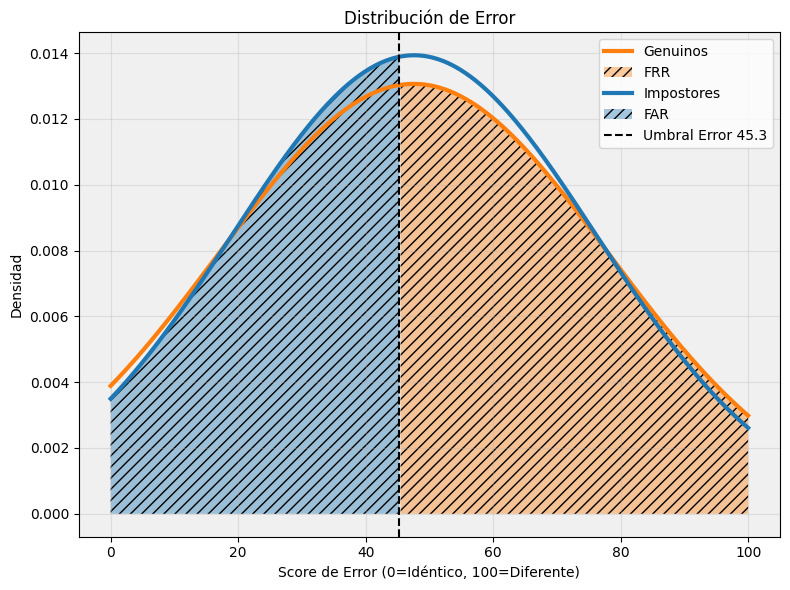

In [17]:
dibujar_distribucion_error(genuinos_train, impostores_train, mejor_umbral)

En segundo lugar, graficamos la curva DET (Detection Error Tradeoff) y el punto operativo, que es el punto (FAR, FRR) dado el umbral escogido. Esta función se la pedimos a Gemini.

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def dibujar_curva_det(genuinos, impostores, umbral):
    """
    Dibuja la curva DET y el punto (FAR, FRR) dado un umbral.
    """
    genuinos = np.array(genuinos)
    impostores = np.array(impostores)
    
    umbrales = np.linspace(0, 100, 1000)
    far_list = []
    frr_list = []
    
    for u in umbrales:
        far = np.mean(impostores >= u) if len(impostores) > 0 else 0
        frr = np.mean(genuinos < u) if len(genuinos) > 0 else 0
        far_list.append(far)
        frr_list.append(frr)
        
    # Buscar el EER (Equal Error Rate: donde la diferencia entre FAR y FRR es mínima)
    diferencias = np.abs(np.array(far_list) - np.array(frr_list))
    idx_eer = np.argmin(diferencias)
    eer_valor = far_list[idx_eer]
    umbral_eer = umbrales[idx_eer] # Umbral correspondiente al EER
    
    print(f"EER (Error): {eer_valor*100:.2f}%")
    print(f"Umbral correspondiente al EER: {umbral_eer:.2f}")

    plt.figure(figsize=(8, 8))
    plt.plot(far_list, frr_list, color='#66b032', lw=3, label='Curva DET')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
    f_op = np.mean(impostores >= umbral)
    r_op = np.mean(genuinos < umbral)
    plt.plot(f_op, r_op, 'ro', markersize=10, label=f'Punto operativo\n(Umbral: {umbral:.2f})')

    plt.title('Curva DET con EER')
    plt.xlabel('Falsa Aceptación (FAR)')
    plt.ylabel('Falso Rechazo (FRR)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    
    plt.tight_layout()
    plt.show()


EER (Error): 50.00%
Umbral correspondiente al EER: 54.55


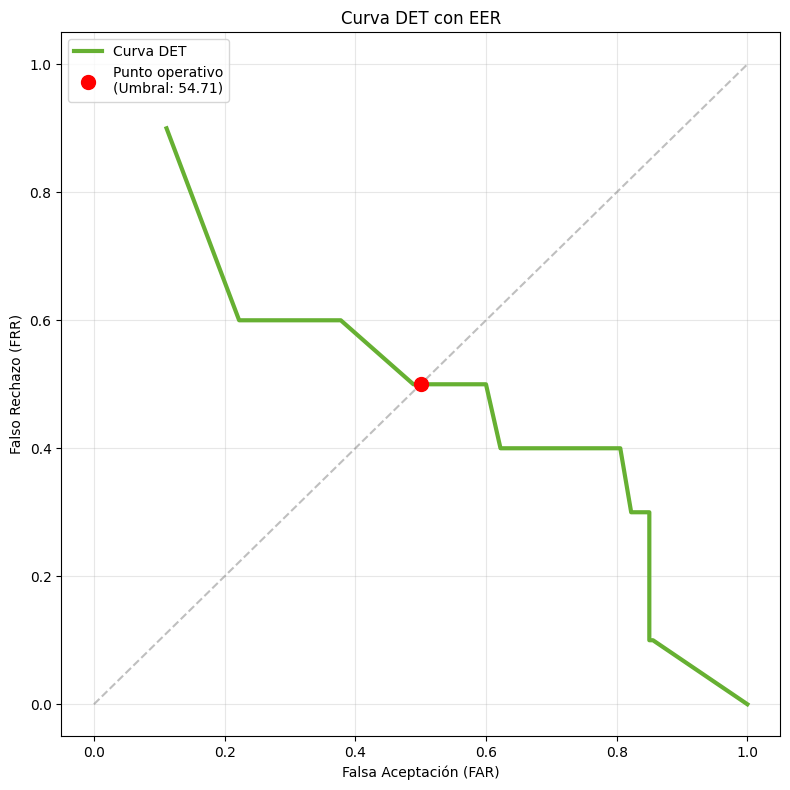

In [19]:
dibujar_curva_det(genuinos_train, impostores_train, mejor_umbral)

#### **Conclusiones**

Se puede observar en la primera gráfica que las distribuciones se encuentran casi solapadas, lo que indica que el sistema tiene dificultades para distinguir entre los usuarios genuinos y los impostores. Esto implica que seguramente haya algún proceso del preprocesamiento que está influyendo al mal funcionamiento de SIFT. Puede deberse a la aplicación del operador Sobel que puede estar eliminando detalles en la huella dactilar. 

Luego, en la curva DET podemos ver que la curva ideal (ajustada a la esquina inferior izquierda) no se consigue. La "curva" obtenida se asemeja a una línea diagonal. Por lo tanto, el sistema no es capaz de obtener un buen rendimiento. No obtante, también podemos observar que hemos escogido un buen umbral de decisión ya que se encuentra en la diagonal discontinua, donde FAR y FRR están equilibrados.

### **Evaluación**
Esta sección está dedicada a evaluar nuevas imágenes. Para ello, hemos adaptado las funciones utilizadas anteriormente para aceptar una imagen de referencia y una batería de imágenes a comparar. Está diseñada con la idea de poder ejecutar sin necesidad de ejecutar antes el código anterior. Únicamente es necesario tener la configuración de SIFT y el umbral los ficheros indicados en `PARAMS_FILE` y `THRESHOLD_FILE`, además de cargar las funciones iniciales de preprocesado.

In [20]:
# Importación de librerías
import json
import numpy as np
import cv2 as cv
import os
import pandas as pd

Preprocesamos las imágenes de prueba:

In [21]:
TEST_PATH = "test"
OUT_TEST_PATH = "output/test"

print(20*"=")
print("PREPROCESADO IMÁGENES DE TEST")
print(20*"=")

print("Paso 1. ROI (Test)")
recortar_roi(TEST_PATH, OUT_TEST_PATH, ventana=500, paso=15)
print("Paso 2. Ecualizar (Test)")
ecualizar_histograma(TEST_PATH, OUT_TEST_PATH)
print("Paso 3. Bilateral (Test)")
aplicar_filtro_bilateral(TEST_PATH, OUT_TEST_PATH)
print("Paso 4. Sobel (Test)")
realzar_crestas(TEST_PATH, OUT_TEST_PATH)
print("Paso 5. Refinar (Test)")
refinar_roi(TEST_PATH, OUT_TEST_PATH)

PREPROCESADO IMÁGENES DE TEST
Paso 1. ROI (Test)
Paso 2. Ecualizar (Test)
Paso 3. Bilateral (Test)
Paso 4. Sobel (Test)
Paso 5. Refinar (Test)


Adaptamos las funciones anteriores:

In [22]:
def cargar_dataset_test(out_path, sift):
    """Carga las imágenes procesadas y genera descriptores SIFT."""

    dataset = []
    
    # Cargamos la batería de imágenes de prueba
    folder = os.path.join(out_path, "test", "refinadas")
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".png")])
        
    for f in files:
        path = os.path.join(folder, f)
        img = cv.imread(path, cv.IMREAD_GRAYSCALE)
        if img is None: 
            continue
        
        kp, des = sift.detectAndCompute(img, None)
        
        if des is not None:
            dataset.append({'filename': f, 'kp': kp, 'des': des})
            
    return dataset

def match_knn_ratio(bf, des1, des2, ratio=0.75, k=2):
    """
    Empareja descriptores con KNN, aplica el test de ratio de Lowe
    y devuelve los matches ordenados.
    """
    knn = bf.knnMatch(des1, des2, k=k)
    good = []

    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair[0], pair[1]

        if m.distance < ratio * n.distance: # ratio de Lowe
            good.append(m)

    return sorted(good, key=lambda x: x.distance)


def calcular_similitud(bf, kp_src, des_src, kp_dst, des_dst, mejor_umbral=-np.inf): 
    """Compara dos conjuntos de descriptores y devuelve inliers, ratio y si es match."""
    inliers = 0
    ratio = 0.0
    es_match = False
    
    if des_src is None or des_dst is None: 
        return inliers, ratio, es_match
    
    matches = match_knn_ratio(bf, des_src, des_dst)
    good_n = len(matches)
    if good_n >= 4:
        src = np.float32([kp_src[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst = np.float32([kp_dst[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        _, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
        if mask is not None:
                inliers = int(mask.sum())
                if len(matches) > 0:
                    ratio = (inliers / len(matches)) * 100.0
                
                if inliers >= 5 and ratio >= mejor_umbral:
                    es_match = True
    return inliers, ratio, es_match

def ejecutar_autenticacion(reference_path, test_path, params, mejor_umbral=-np.inf):
    sift = cv.SIFT_create(**params)
    bf = cv.BFMatcher()
    # Cargamos las imágenes de test
    dataset = cargar_dataset_test(test_path, sift)

    img = cv.imread(reference_path, cv.IMREAD_GRAYSCALE)
    # Obtenemos los keypoints y descriptores de la imagen de referencia
    kp, des = sift.detectAndCompute(img, None)
    
    resumen = []
    # Evaluamos imagen_ref vs imagenes_test
    for i in range(0, len(dataset)):
        img_B = dataset[i]
        inliers, ratio, es_match = calcular_similitud(bf, kp, des, img_B['kp'], img_B['des'], mejor_umbral)
        resumen.append([reference_path.replace('\\', '/').split('/')[-1], img_B['filename'], inliers, ratio, es_match])
    return resumen

A continuación, le pedimos a Gemini una función para ofrecerle al usuario la posibilidad de introducir la huella que quiere tomar de referencia.

In [23]:
# Función de Gemini
def seleccionar_imagen_referencia(carpeta_huellas):
    """
    Permite al usuario seleccionar una imagen de referencia de una carpeta
    y devuelve la ruta de la imagen seleccionada.
    """
    if not os.path.exists(carpeta_huellas):
        print(f"ERROR: No existe la carpeta {carpeta_huellas}")
        return None
    
    # Imágenes que oferta al usuario
    imagenes = sorted([f for f in os.listdir(carpeta_huellas) if f.lower().endswith('.png')])
    
    if not imagenes:
        print(f"ERROR: No se encontraron imágenes en {carpeta_huellas}")
        return None
    
    print("\nSelección de la imagen de referencia:")
    for i, img in enumerate(imagenes):
        print(f"[{i}] {img}")
    
    try:
        sel_img = int(input(f"Elige ID de imagen (0-{len(imagenes)-1}): ").strip())
        ref_imagen = imagenes[sel_img]
    except (ValueError, IndexError):
        print(f"Selección inválida. Usando la primera: {imagenes[0]}")
        ref_imagen = imagenes[0]
    
    reference_path = os.path.join(carpeta_huellas, ref_imagen)
    print(f"\nImagen de referencia: {ref_imagen.split("/")[-1]}\n")
    
    return reference_path

A continuación, utilizamos las funciones definidas para probar el sistema con datos de prueba y mostramos el resumen de los resultados.

In [24]:

PARAMS_FILE = "mejor_config_sift.json"
THRESHOLD_FILE = "mejor_umbral.txt"

with open(PARAMS_FILE, 'r') as f: 
    mejor_config = json.load(f)
    print(f"Configuración cargada: {mejor_config}")
with open(THRESHOLD_FILE, 'r') as f:
    mejor_umbral = float(f.read())

reference_path = seleccionar_imagen_referencia("output/test/refinadas")
resumen = ejecutar_autenticacion(reference_path,
                       "output",
                       mejor_config,
                       mejor_umbral)
df = pd.DataFrame(resumen, columns=["img A", "img B", "inliers", "ratio", "es_match"])
df

Configuración cargada: {'nfeatures': 6000, 'contrastThreshold': 0.04, 'edgeThreshold': 10, 'sigma': 1.6}

Selección de la imagen de referencia:
[0] crd_0811f_01.png
[1] crd_0811s_01.png
[2] crd_0812f_01.png
[3] crd_0812s_01.png
[4] crd_0813f_01.png
[5] crd_0813s_01.png
[6] crd_0814f_01.png
[7] crd_0814s_01.png
[8] crd_0815f_01.png
[9] crd_0815s_01.png

Imagen de referencia: crd_0811f_01.png



,img A,img B,inliers,ratio,es_match
0,crd_0811f_01.png,crd_0811f_01.png,5046,100.000000,True
1,crd_0811f_01.png,crd_0811s_01.png,4,80.000000,False
2,crd_0811f_01.png,crd_0812f_01.png,4,44.444444,False
3,crd_0811f_01.png,crd_0812s_01.png,0,0.000000,False
4,crd_0811f_01.png,crd_0813f_01.png,4,50.000000,False
5,crd_0811f_01.png,crd_0813s_01.png,4,80.000000,False
6,crd_0811f_01.png,crd_0814f_01.png,4,80.000000,False
7,crd_0811f_01.png,crd_0814s_01.png,4,57.142857,False
8,crd_0811f_01.png,crd_0815f_01.png,4,57.142857,False
9,crd_0811f_01.png,crd_0815s_01.png,4,100.000000,False


### **Conclusión**
Tras las pruebas realizadas, el sistema no es capaz de verificar si dos huellas corresponden al mismo usuario. Como se observó anteriormente, las distribuciones de los genuinos e impostores se solapan, por que lo que no discrimina bien y no da buenos resultados. 

Asimismo, hemos detectado que quizás el preprocesamiento realizado no ha sido el más adecuado para la posterior implementación del algoritmo SIFT. Por lo que sería algo que mejorar en trabajos futuros.

En conclusión, la hipótesis planteada no obtiene resultados satisfactorios.

---

## **Hipótesis basada en IA**

La hipótesis de IA se basa en el ejemplo propuesto en el campus sobre el uso de una red siamesa convolutiva para la comparación de huellas dactilares, con la cual se utilizarán los embeddings generados por la red para luego comparar mediante la distancia coseno. Antes de realizar esa comparación, se aplica un preprocesado para mejorar la calidad de las imagenes de huellas dactilares. Esta hipótesis con IA tiene la ventaja de que el modelo aprenderá automáticamente las características más relevantes para comparar las huellas, sim embargo, tiene la limitación de que requiere más datos.

El enfoque utilizado ha sido el mismo que la propuesta de la IA, pero con algunos añadidos para su realización, como el uso de una clase para cargar el dataset de huellas dactilares para que el modelo sea capaz de encontrar las características cuando las huellas son iguales y cuando son diferentes. Además, se ha implementado una función basada en la distancia del coseno y euclídea (que al normalizarlas son equivalentes); esto se implementó para poder utilizar la red siamesa convolutiva de [`jingpingjiao`](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py). 

## **Desarrollo**
### **Librerías necesarias**
Se han utilizado las siguientes librerías:


In [25]:
import os
import cv2 as cv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.stats import norm
from datetime import datetime
from pytz import timezone


### **Preprocesamiento de imágenes**
A continuación, se exponen los diferentes pasos del preprocesado de las imágenes llevados a cabo. Estos pasos son secuenciales, es decir, cada uno se aplica a los resultados del paso anterior. Los pasos son los siguientes:
1. Buscar y segmentar la ROI
2. Ecualizar y normalizar el histograma
3. Aplicar un filtro bilateral
4. Aplicar un realce de crestas



#### **Buscar y segmentar la ROI**
El objetivo del primer paso del preprocesado es obtener el núcleo de la huella. Según el estudio de Simón-Zorita, este paso es realmente importante para conseguir un buen preprocesado de huellas.

Para ello, creamos dos funciones: `mejor_roi()` y `recortar_roi()`.
- `mejor_roi()`: Esta función obtiene la región de interés de una imagen. Dicha región de interés se define como la región de tamaño `ventana`x`ventana` donde más píxeles negros hay. Para ello, se recorre la imagen con un kernel de tamaño `ventana`x`ventana` dando pasos de `paso` píxeles y se obtiene la suma de píxeles negros. Una vez recorrida toda la imagen, se devuelven las coordenadas donde inicia la ventana y el ancho y alto de la misma, con lo que se pueden calcular las coordenadas de la región con mayor número de píxeles negros.
- `recortar_roi()`: Esta función guarda las regiones de interés de todas las imágenes que se encuentran en la ruta `db_path` en disco, en un directorio `out_path` especificado. Para ello, hace uso de la función `mejor_roi()` tras convertir las imágenes a escala de grises y binarizarlas usando `cv.THRESH_BINARY + cv.THRESH_OTSU`. La binarización combinada es sugerencia de ChatGPT para que el umbral se establezca dinámicamente.

Pedimos a Gemini y fragmento de código para aceptar tanto la estructura de 'data' como de 'test' y acelerar el procesamiento.

In [26]:
def mejor_roi(image, ventana=500, paso=20):
    """Encuentra la región de interés (ROI) en la imagen que contiene la mayor cantidad de píxeles negros."""

    H, W = image.shape
    w = min(ventana, W, H)
    h = min(ventana, W, H)
    mejor_ventana = (0, 0, w, h)
    mejor_suma = -1

    for y in range(0, H - h + 1, paso):
        for x in range(0, W - w + 1, paso):
            region = image[y:y+h, x:x+w]
            suma = np.sum(region == 0)

            if suma > mejor_suma:
                mejor_suma = suma
                mejor_ventana = (x, y, w, h)

    return mejor_ventana

def recortar_roi(db_path, out_path, ventana=500, paso=15):
    """
    Detecta si db_path contiene carpetas de usuarios (Data) o imágenes sueltas (Test)
    y aplica el recorte ROI guardando en la estructura correspondiente.
    """

    if not os.path.exists(db_path):
        return

    items = os.listdir(db_path)

    # Código proporcionado por Gemini para aceptar 
    # tanto la estructura de 'data' como de 'test'
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        dst_folder = os.path.join(out_path, "roi")
        origen_dest_pares.append((db_path, dst_folder))
    else: # data
        for user in users:
            src = os.path.join(db_path, user)
            dst = os.path.join(out_path, user, "roi")
            origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]
    # ---

        for filename in files:
            img_path = os.path.join(src_dir, filename)
            img = cv.imread(img_path)

            if img is None: continue

            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            _, image = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU) # Otsu: sugerencia de GPT
            x, y, w, h = mejor_roi(image, ventana=ventana, paso=paso)
            roi = img[y:y+h, x:x+w]
            cv.imwrite(os.path.join(dst_dir, filename), roi)

#### **Ecualizar y normalizar el histograma**
El siguiente paso a realizar es ecualizar y normalizar el histograma. Con esto, queremos mejorar el contraste de la imagen. Esta técnica la aprendimos en prácticas anteriores donde ecualizar el histograma de una imagen nos permitía encontrar un equilibrio entre brillos y sombras. Para ello,  usamos la función `ecualizar_histograma()`.
- `ecualizar_histograma()`: Esta función, para cada imagen que se encuentra en `db_path`, convierte la imagen a escala de grises, ecualiza el histograma con `cv.equalizeHist()` y la guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en la función anterior para procesar datos de entrenamiento y de evaluación.

In [27]:
def ecualizar_histograma(db_path, out_path):
    """Ecualiza y normaliza el histograma de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "roi")
        dst = os.path.join(out_path, "equalized")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "roi")
            dst = os.path.join(out_path, user, "equalized")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            equalized = cv.equalizeHist(gray)
            cv.imwrite(os.path.join(dst_dir, filename), equalized)

#### **Aplicar un filtro bilateral**
A continuación, procedemos con la aplicación del filtro bilateral, cuyo objetivo es eliminar ruido pero no las texturas. Este procedimiento lo aprendimos en prácticas anteriores donde vimos la efectividad de los distintos tipos de filtros. De dicha práctica, sacamos la conclusión de que si no queremos difuminar demasiado la imagen, debíamos utilizar valores bajos de *sigma*. Para aplicarlo, definimos la función `aplicar_filtro_bilateral()`.
- `aplicar_filtro_bilateral()`: Esta función convierte cada imagen ubicada dentro de `db_path` en escala de grises y le aplica el filtro bilateral con la función `cv.bilateralFilter`. Los resultados los guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [28]:
def aplicar_filtro_bilateral(db_path, out_path):
    """Aplica un filtro bilateral a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "equalized")
        dst = os.path.join(out_path, "bilateral_filter")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "equalized")
            dst = os.path.join(out_path, user, "bilateral_filter")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            bilateral = cv.bilateralFilter(gray, d=10, sigmaColor=10, sigmaSpace=10)
            cv.imwrite(os.path.join(dst_dir, filename), bilateral)

#### **Aplicar un realce de crestas**
El siguiente paso, es realizar el realce de crestas con operadores de bordes Sobel con el fin de poder discriminar mejor entre crestas y valles. Este paso es una implementación de la teoría explicada en la primera parte de la asignatura. Para ello, creamos la función `realzar_crestas()`.
- `realzar_crestas()`:  Esta función convierte a escala de grises cada imagen de la base de datos ubicada en `db_path` y le aplica los operadores de Sobel, tanto verticales como horizontales. La ponderación de cada gradiente la obtuvimos de la [documentación de OpenCV](#https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html). Por último, se normaliza la imagen resultante y se pasa a `CV_8U` para solventar el *warning* `[ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.`. Esto fue la solución al *warning* que nos dio ChatGPT. Los resultados los guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [29]:
def realzar_crestas(db_path, out_path):
    """Aplica un realce de crestas a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "bilateral_filter")
        dst = os.path.join(out_path, "sobel")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "bilateral_filter")
            dst = os.path.join(out_path, user, "sobel")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
            sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
            # https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
            abs_grad_x = cv.convertScaleAbs(sobelx)
            abs_grad_y = cv.convertScaleAbs(sobely)
            grad = cv.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)
            sobel_8u = cv.normalize(grad, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8) # Código de GPT para solventar warning: [ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
            cv.imwrite(os.path.join(dst_dir, filename), sobel_8u)

#### **Ejecución del preprocesado**
A continuación, ejecutamos el preprocesado usando las funciones definidas anteriormente. El resultado será un nuevo directorio `output` que contendrá subdirectorios con los nombres de los archivos de los diferentes usuarios. Todos ellos contienen otros directorios con las salidas del preprocesado de las imágenes de la base de datos.

In [30]:
DB_PATH = r"data"
OUT_PATH = "output"

print(20*"=")
print("PREPROCESADO BASE DE DATOS (DATA)")
print(20*"=")

print("Paso 1. ROI (Data)")
recortar_roi(DB_PATH, OUT_PATH, ventana=500, paso=15)  
print("Paso 2. Ecualizar (Data)")
ecualizar_histograma(DB_PATH, OUT_PATH)
print("Paso 3. Bilateral (Data)")
aplicar_filtro_bilateral(DB_PATH, OUT_PATH)
print("Paso 4. Sobel (Data)")
realzar_crestas(DB_PATH, OUT_PATH)

PREPROCESADO BASE DE DATOS (DATA)
Paso 1. ROI (Data)
Paso 2. Ecualizar (Data)
Paso 3. Bilateral (Data)
Paso 4. Sobel (Data)


Ahora, ilustraremos los resultados del preprocesado del usuario *crd_0811f*:
- Original

    ![crd_0811f_01-original.png](images/crd_0811f/crd_0811f_01.png)
- ROI

    ![crd_0811f_01-roi.png](images/crd_0811f/roi/crd_0811f_01.png)
- Ecualizada

    ![crd_0811f_01-ecualizada.png](images/crd_0811f/equalized/crd_0811f_01.png)
- Filtrada

    ![crd_0811f_01-filtrada.png](images/crd_0811f/bilateral_filter/crd_0811f_01.png)
- Sobel

    ![crd_0811f_01-sobel.png](images/crd_0811f/sobel/crd_0811f_01.png)

### **Red neuronal para extracción de características**
Para la extracción de características hemos utilizado una red neuronal convolucional llamada `SiameseCNN`, propuesta como solución en el enunciado de la práctica. Para definirla, hemos adaptado el código que se encuentra en el [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py). Hemos adaptado la estructura de la red a las dimensiones de nuestros datos y quitamos las capas de Batch Normalization, que no pretendemos usarlas.

Las bloques de dicha red son los siguientes:

- **Bloque convolucional**: Se encarga de extraer las características de las imágenes. Utiliza la función de activación ReLu y una capa de MaxPooling para reducir la dimensionalidad de las características.

- **Bloque de Fully Connected**: Transforma las características en un vector.

Luego, su método forward_once representa la retropropagación hacia adelante aplicada a una imagen; mientras que el método forward lo realiza para dos imágenes, siguiendo la estructura siamesa.

Preguntamos a ChatGPT la diferencia entre la distancia coseno y el Contrastive Loss (que usa la distancia euclídea) que se usa en el código del repositorio y nos indicó que si queríamos usar la distancia coseno, podíamos normalizar los vectores con `F.normalize` para que ambas medidas sean equivalentes. Así, podemos reciclar el código del repositorio.


In [31]:
# Código reciclado del repositorio de GitHub
class Flatten(nn.Module):

    def forward(self, input):
        return input.view(input.size(0), -1)
    
# Código del repositorio de GitHub adaptado
class SiameseCNN(nn.Module):
    """ Red Siamesa para extracción de características de huellas dactilares."""

    def __init__(self, embedding_dim=128):
        super().__init__()
        
        # bloque convolucional
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 7, padding=3), # adaptamos los canales
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            Flatten(),
        )
        
        # bloque fully connected
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512), # adaptamos los canales
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
    
    def forward_once(self, x):
        # print(x.shape)
        x = self.cnn(x)
        # print(x.shape)
        x = self.fc(x)
        # Sugerencia de ChatGPT: hace que la distancia euclídea y coseno sean equivalentes
        return F.normalize(x, p=2, dim=1)
    
    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

A continuación, creamos el modelo:

In [32]:
OUT_PATH = "output"

modelo = SiameseCNN(embedding_dim=128)

### **Creación del Dataset**
Antes de proceder con el entrenamiento del modelo, es necesario definir la clase `FingerprintPairsDataset`, encargada de generar los ejemplos de entrenamiento. Para ello, adaptamos el código del [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py) modificando los métodos `__init__()` y `__getitem__()` para nuestros datos.

Antes de eso, realizamos un preprocesado previo a introducir las imágenes al modelo. Para ello, definimos la función auxiliar `cargar_imagen()`, que carga una imagen en escala de grises, la redimensiona y la convierte a un tensor normalizado. Esta función se la pedimos a Gemini.

Se inicializa creando pares de imágenes de la siguiente manera:
-  Dos huellas del mismo usuario: `label=1`.
- Dos huellas de distintos usuarios: `label=0`.

Esto se realiza así para enseñar a la red a distinguir entre huellas dactilares similares y diferentes.


In [33]:

def cargar_imagen(img_path, size=224):
    """ 
    Carga una imagen en escala de grises, la redimensiona
    y la convierte en tensor normalizado.
    """
    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"No se pudo cargar: {img_path}")

    img = cv.resize(img, (size, size)) # Redimensionamos la imagen
    tensor = torch.tensor(img, dtype=torch.float32) / 255.0 # Convertimos a tensor y normalizamos

    return tensor.unsqueeze(0) # [1, H, W]


class FingerprintPairsDataset(Dataset):
    """ Dataset de pares de huellas para entrenamiento del modelo de red siamesa."""

    def __init__(self, out_path): 
        self.pairs = []
        self.labels = []
        
        # La lógica de navegación entre directorios la reciclamos de la hipótesis clásica
        usuarios = sorted(os.listdir(out_path))
        
        # Mismo usuario -> 1
        for user in usuarios:
            folder = os.path.join(out_path, user, "sobel")
            if not os.path.isdir(folder):
                continue
            
            imgs = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
            if len(imgs) >= 2:
                self.pairs.append((os.path.join(folder, imgs[0]), os.path.join(folder, imgs[1])))
                self.labels.append(1)
        
        # Usuarios diferentes -> 0
        for i, u1 in enumerate(usuarios):
            for u2 in usuarios[i+1:]:
                f1 = os.path.join(out_path, u1, "sobel")
                f2 = os.path.join(out_path, u2, "sobel")

                if not os.path.isdir(f1) or not os.path.isdir(f2):
                    continue

                imgs1 = sorted([f for f in os.listdir(f1) if f.endswith(".png")])
                imgs2 = sorted([f for f in os.listdir(f2) if f.endswith(".png")])

                if imgs1 and imgs2:
                    self.pairs.append((os.path.join(f1, imgs1[0]), os.path.join(f2, imgs2[0])))
                    self.labels.append(0)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        img1, img2 = self.pairs[idx]
        t1 = cargar_imagen(img1)
        t2 = cargar_imagen(img2)
        # devolvemos también las rutas para poder mostrarlas en el resumen
        return t1, t2, torch.tensor(self.labels[idx], dtype=torch.float32), img1, img2

### Entrenamiento de la red Siamesa
Para entrenar la red siamesa necesitamos definir algunas funciones y clases auxiliares:
- Clase `ContrastiveLoss`: Esta clase calcula la pérdida Contrastive Loss, que se basa en la distancia euclídea. Este método lo cogimos del [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py).
    - Si son la misma persona: La formula castiga a la red si los vectores de las dos imágenes están lejos entre sí.
    - Si son personas diferentes: La formula castiga a la red si los vectores de las dos imágenes están cerca entre sí.


In [34]:
# Código del repositorio de GitHub
class ContrastiveLoss(torch.nn.Module):

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, input1, input2, y):
        diff = input1 - input2
        dist_sq = torch.sum(torch.pow(diff, 2), 1)
        dist = torch.sqrt(dist_sq + 1e-9) # Solución de Gemini: sumar epsilon para solucionar loss=nan
        mdist = self.margin - dist
        dist = torch.clamp(mdist, min=0.0)
        loss = y * dist_sq + (1 - y) * torch.pow(dist, 2)
        loss = torch.sum(loss) / 2.0 / input1.size()[0]
        return loss

La siguiente función la cogimos del [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py) y se utiliza para obtener el timestamp de la ejecución del modelo para luego guardarlo. Cambiamos de 'US/Eastern' a 'Atlantic/Canary'.

In [35]:
def cur_time():
    fmt = '%Y-%m-%d %H:%M:%S %Z%z'
    eastern = timezone('Atlantic/Canary')
    loc_dt = datetime.now(eastern)
    return loc_dt.strftime(fmt).replace(' ', '_')

La siguiente función `threashold_contrastive_loss()` también la obtuvimos del [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py). Devuelve la predicción del modelo (0: distinto usuario; 1: mismo usuario) y la distancia euclidiana obtenida.

In [36]:
def threashold_contrastive_loss(input1, input2, m=1.0):
    """dist < m --> 1 else 0"""
    diff = input1 - input2
    dist_sq = torch.sum(torch.pow(diff, 2), 1)
    dist = torch.sqrt(dist_sq)
    threashold = dist.clone()
    threashold.data.fill_(m)
    return (dist < threashold).float().view(-1, 1), dist


La función `test_against_data()` es una adaptación del proporcionado en el [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py). Se encarga de imprimir la exactitud del modelo sobre los datos de entrenamiento. Además, devuelve las distancias de los genuinos e impostores para su posterior representación. También, devuelve un resumen de los resultados.

In [37]:

def test_against_data(modelo, label, dataset):
    # Accuracy del entrenamiento
    modelo.eval()
    correct = 0.0
    total = 0.0
    genuinos_dist = [] # lista para almacenar ratios de genuinos 
    impostores_dist = [] # lista para almacenar ratios de impostores 
    resumen = [] # lista para almacenar resultados
    for img1, img2, labels, img1_path, img2_path in dataset:
        labels = labels.view(-1, 1).float()
        output1, output2 = modelo(img1, img2)
        output_labels, dists = threashold_contrastive_loss(output1, output2)
        
        # Solución de Gemini a error de tamaño:
        # tenemos que separar los datos del batch uno por uno
        dists_np = dists.detach().cpu().numpy().flatten()
        labels_np = labels.detach().cpu().numpy().flatten()
        preds_np = output_labels.detach().cpu().numpy().flatten()

        for i in range(len(labels_np)):
            valor_distancia = float(dists_np[i])
            valor_real = int(labels_np[i])
            
            if valor_real > 0.5:
                genuinos_dist.append(valor_distancia)
            else:
                impostores_dist.append(valor_distancia)
            
            # resumen de resultados
            resumen.append([img1_path[i].replace("\\", "/").split("/")[-1], img2_path[i].replace("\\", "/").split("/")[-1], valor_real, int(preds_np[i]), valor_distancia])
    
        total += labels.size(0)
        correct += (output_labels == labels).sum().item() # .item() corrección de ChatGPT

    print('Accuracy del modelo en las {} {} imágenes: {} %%'.format(total, label, (100 * correct / total)))
    return genuinos_dist, impostores_dist, resumen

A continuación, definimos la función `train()`, que se ocupará de entrenar el modelo. Es una adaptación del método proporcionado en el [repositorio de GitHub de jingpingjiao](https://github.com/jingpingjiao/siamese_cnn/blob/master/siamese.py) a nuestras clases y funciones.

In [38]:
def train(modelo, out_path, epochs=5, lr=1e-4):
    """ Entrena el modelo siamesa con pares de huellas. """

    dataset = FingerprintPairsDataset(out_path)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterion = ContrastiveLoss()
    
    modelo.train()
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2, label, _, _ in dataloader:
            output1, output2 = modelo(img1, img2)
            loss = criterion(output1, output2, label)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")
    
    print("Entrenamiento terminado.\n")
    # Accuracy del entrenamiento
    genuinos_ratios, impostores_ratios, resumen = test_against_data(modelo, 'training', dataloader)

    # Guardar el modelo
    timestamp_seguro = cur_time().replace(":", "-").replace(" ", "_") # Solución de ChatGPT para solucionar problemas de nombres en Windows
    model_file_name = "{}_{}".format(timestamp_seguro, "siamese.pkl")
    torch.save(modelo.state_dict(), model_file_name)
    print("Modelo guardado en {}".format(model_file_name))
    return modelo, genuinos_ratios, impostores_ratios, resumen


A continuación, entrenamos el modelo e imprimimos el resumen de los resultados.

In [39]:
modelo, genuinos_dist, impostores_dist, resumen = train(
    modelo=modelo,
    out_path=OUT_PATH,
    epochs=20,
    lr=1e-4
)

df = pd.DataFrame(resumen, columns=["img A", "img B", "valor real", "prediccion", "distancia"])
df

Epoch 1/20 - Loss: 1.9319
Epoch 2/20 - Loss: 1.1743
Epoch 3/20 - Loss: 0.7938
Epoch 4/20 - Loss: 0.3929
Epoch 5/20 - Loss: 0.2191
Epoch 6/20 - Loss: 0.1868
Epoch 7/20 - Loss: 0.1730
Epoch 8/20 - Loss: 0.1454
Epoch 9/20 - Loss: 0.1493
Epoch 10/20 - Loss: 0.1385
Epoch 11/20 - Loss: 0.1329
Epoch 12/20 - Loss: 0.1416
Epoch 13/20 - Loss: 0.1551
Epoch 14/20 - Loss: 0.1450
Epoch 15/20 - Loss: 0.1511
Epoch 16/20 - Loss: 0.1439
Epoch 17/20 - Loss: 0.1407
Epoch 18/20 - Loss: 0.1402
Epoch 19/20 - Loss: 0.1359
Epoch 20/20 - Loss: 0.1350
Entrenamiento terminado.

Accuracy del modelo en las 66.0 training imágenes: 96.96969696969697 %%
Modelo guardado en 2025-12-14_18-37-33_WET+0000_siamese.pkl


,img A,img B,valor real,prediccion,distancia
0,crd_0817f_01.png,crd_0817s_01.png,1,1,0.048822
1,crd_0815f_01.png,crd_0815s_01.png,1,1,0.027964
2,crd_0812f_01.png,crd_0815f_01.png,0,0,1.025866
3,crd_0811f_01.png,crd_0820f_01.png,0,0,1.076935
4,crd_0814f_01.png,crd_0811f_01.png,0,0,1.073284
...,...,...,...,...,...
61,crd_0816f_01.png,crd_0817f_01.png,0,0,1.005643
62,crd_0811f_01.png,crd_0818f_01.png,0,0,1.195763
63,crd_0817f_01.png,crd_0811f_01.png,0,0,1.040445
64,crd_0813f_01.png,crd_0816f_01.png,0,0,1.033928


A continuación, vemos cómo ha rendido el modelo observando los falsos/verdaderos positivos y negativos.

In [40]:
# Función pedida a Gemini para extraer el identificador de usuario
def extraer_id_numerico(nombre_archivo):
    """Extrae el identificador de usuario del nombre del archivo introducido."""
    # Convertimos a string y quitamos extensión por seguridad
    s = str(nombre_archivo).split('.')[0] 
    
    # Si la cadena no está vacía, ignoramos el último caracter
    if len(s) > 0:
        s = s[:-1] 
    
    # Filtramos para dejar SOLO los números ("crd_0811" -> "0811")
    id_numerico = ''.join(filter(str.isdigit, s))
    
    return id_numerico

def clasificar(fila):
    """
    Clasifica un resultado en: True Positive, True Negative,
    False Positive o False Negative."""
    id_a = extraer_id_numerico(fila['img A'])
    id_b = extraer_id_numerico(fila['img B'])
    misma_persona = (id_a == id_b)
    resultado = fila['prediccion']
    
    if misma_persona and resultado:
        return "TP"
    elif not misma_persona and not resultado:
        return "TN"
    elif not misma_persona and resultado:
        return "FP"
    elif misma_persona and not resultado:
        return "FN"
        
    return "Error"
# Aplicamos la función clasificar a cada fila del dataframe
df["result"] = df.apply(clasificar, axis=1)
print(df[["img A", "img B", "prediccion", "result"]].head())
# Mostramos el conteo de cada resultado posible
conteo = df["result"].value_counts()
print(conteo)
# Pedido a Gemini para calcular el accuracy
TP = conteo.get("TP", 0)
TN = conteo.get("TN", 0)
FP = conteo.get("FP", 0)
FN = conteo.get("FN", 0)
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN) > 0 else 0
print(f"Accuracy (Exactitud): {accuracy*100:.2f}%")

              img A             img B  prediccion result
0  crd_0817f_01.png  crd_0817s_01.png           1     TP
1  crd_0815f_01.png  crd_0815s_01.png           1     TP
2  crd_0812f_01.png  crd_0815f_01.png           0     TN
3  crd_0811f_01.png  crd_0820f_01.png           0     TN
4  crd_0814f_01.png  crd_0811f_01.png           0     TN
result
TN    53
TP    12
FP     1
Name: count, dtype: int64
Accuracy (Exactitud): 98.48%


A continuación, buscamos el umbral óptimo. Este es aquel que obtiene un valor equilibrado de FAR (falsa aceptación) y FRR (falso rechazo). Luego, guardamos el umbral en un fichero para su posterior uso. La función se la pedimos a ChatGPT. Antes de eso, necesitamos convertir los valores de distancias a similitudes para poder trabajar en las mismas unidades que la hipótesis clásica. Esta función también se la pedimos a ChatGPT. Asimismo, guardamos el umbral en un fichero para poder rescatarlo posteriormente.

In [41]:
# Función pedida a ChatGPT
def convertir_dist_a_sim(distancias):
    """Convierte distancias euclidianas a similitud."""
    dists = np.array(distancias)
    similitudes = 100.0 / (1.0 + dists)
    
    return similitudes.tolist()


# Función pedida a ChatGPT
def calcular_umbral_optimo(genuinos, impostores):
    """Calcula el umbral óptimo, donde FRR-FAR es mínimo."""
    umbrales = np.linspace(0, 100, 500)
    gen_arr, imp_arr = np.array(genuinos), np.array(impostores)
    diffs = []
    for u in umbrales:
        frr = np.sum(gen_arr < u) / len(gen_arr) if len(gen_arr) else 0
        far = np.sum(imp_arr >= u) / len(imp_arr) if len(imp_arr) else 0
        diffs.append(abs(frr*100 - far*100))
    return umbrales[np.argmin(diffs)]


In [42]:
genuinos_sim = convertir_dist_a_sim(genuinos_dist)
impostores_sim = convertir_dist_a_sim(impostores_dist)
mejor_umbral_sim = calcular_umbral_optimo(genuinos_sim, impostores_sim)
print(f"Umbral (Similitud): {mejor_umbral_sim:.2f}%")

THRESHOLD_FILE = "mejor_umbral_ia.txt"
with open(THRESHOLD_FILE, 'w') as f:
    f.write(str(mejor_umbral_sim))

Umbral (Similitud): 50.10%


### **Visualización de los resultados**
A continuación, graficamos el rendimiento obtenido.

En primer lugar, graficamos las distribuciones de error del verificador de huellas digitales. El caso ideal sería que los genuinos se agrupen hacia la izquierda, donde el error es menor, y los impostores a la derecha, donde el error es mayor. Esta función se la pedimos a Gemini.

In [43]:
def dibujar_distribucion_error(genuinos_similitud, impostores_similitud, umbral_similitud):
    plt.figure(figsize=(8, 6))

    # Error = 100 - Similitud.
    gen_err = [100 - x for x in genuinos_similitud]
    imp_err = [100 - x for x in impostores_similitud]
    umbral_error = 100 - umbral_similitud
    
    x = np.linspace(0, 100, 500)
    plt.gca().set_facecolor('#f0f0f0') 

    # Genuinos
    if len(gen_err) > 1:
        mu, std = norm.fit(gen_err)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:orange', lw=3, label='Genuinos')
        
        # FRR (Falso Rechazo)
        plt.fill_between(x, y, 0, where=(x > umbral_error), 
                         facecolor='tab:orange', alpha=0.4, hatch='///', label='FRR')

    # Impostores
    if len(imp_err) > 1:
        mu, std = norm.fit(imp_err)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:blue', lw=3, label='Impostores')
        
        # FAR (Falsa Aceptación)
        plt.fill_between(x, y, 0, where=(x <= umbral_error), 
                         facecolor='tab:blue', alpha=0.4, hatch='///', label='FAR')

    # Umbral
    plt.axvline(x=umbral_error, color='k', linestyle='--', label=f'Umbral Error {umbral_error:.1f}')
    
    plt.title('Distribución de Error')
    plt.xlabel('Score de Error (0=Idéntico, 100=Diferente)')
    plt.ylabel('Densidad')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



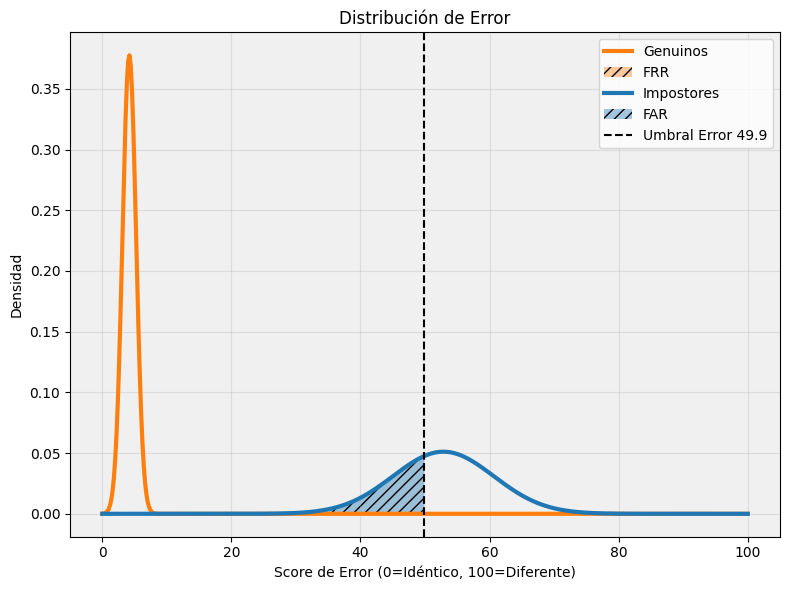

In [44]:
dibujar_distribucion_error(genuinos_sim, impostores_sim, mejor_umbral_sim)

En segundo lugar, graficamos la curva DET (Detection Error Tradeoff) y el punto operativo, que es el punto (FAR, FRR) dado el umbral escogido. Esta función se la pedimos a Gemini.

In [45]:
def dibujar_curva_det(genuinos, impostores, umbral):
    """
    Dibuja la curva DET y el punto (FAR, FRR) dado un umbral.
    """
    genuinos = np.array(genuinos)
    impostores = np.array(impostores)
    
    umbrales = np.linspace(0, 100, 1000)
    far_list = []
    frr_list = []
    
    for u in umbrales:
        far = np.mean(impostores >= u) if len(impostores) > 0 else 0
        frr = np.mean(genuinos < u) if len(genuinos) > 0 else 0
        far_list.append(far)
        frr_list.append(frr)
        
    # Buscar el EER (Equal Error Rate: donde la diferencia entre FAR y FRR es mínima)
    diferencias = np.abs(np.array(far_list) - np.array(frr_list))
    idx_eer = np.argmin(diferencias)
    eer_valor = far_list[idx_eer]
    umbral_eer = umbrales[idx_eer] # Umbral correspondiente al EER
    
    print(f"EER (Error): {eer_valor*100:.2f}%")
    print(f"Umbral correspondiente al EER: {umbral_eer:.2f}")

    plt.figure(figsize=(8, 8))
    plt.plot(far_list, frr_list, color='#66b032', lw=3, label='Curva DET')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
    f_op = np.mean(impostores >= umbral)
    r_op = np.mean(genuinos < umbral)
    plt.plot(f_op, r_op, 'ro', markersize=10, label=f'Punto operativo\n(Umbral: {umbral:.2f})')

    plt.title('Curva DET con EER')
    plt.xlabel('Falsa Aceptación (FAR)')
    plt.ylabel('Falso Rechazo (FRR)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    
    plt.tight_layout()
    plt.show()

EER (Error): 1.82%
Umbral correspondiente al EER: 50.15


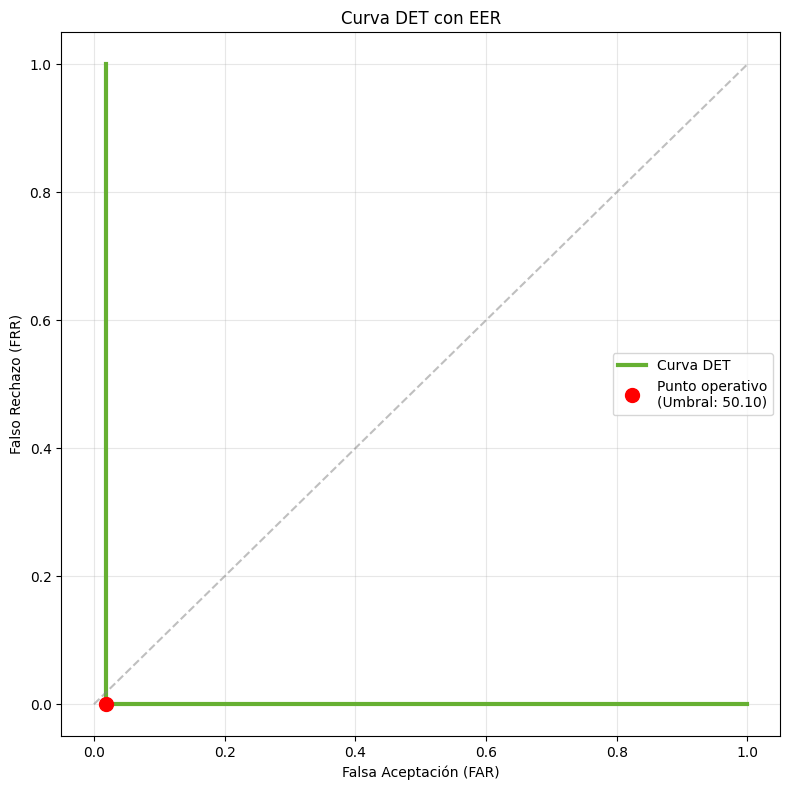

In [46]:
dibujar_curva_det(genuinos_sim, impostores_sim, mejor_umbral_sim)

#### **Conclusiones**

Se puede observar en la primera gráfica que las distribuciones se encuentran separadas, lo que indica que el sistema es capaz de distinguir entre los usuarios genuinos y los impostores. Sobre el conjunto de entrenamiento se obtuvo un 100% de accuracy, por lo que puede verificar correctamente las huellas dactilares. No obstante, habría que ver cómo funciona con nuevos datos que el modelo no ha visto.

Luego, en la curva DET podemos ver que la curva ideal (ajustada a la esquina inferior izquierda) se consigue y el error es nulo, es decir, el FAR y FRR son nulos también, no hay falsa aceptación ni falsos rechazos.

Por lo que, este modelo actúa con un gran rendimiento.

### **Evaluación**
Esta sección está dedicada a evaluar nuevas imágenes. Para ello, hemos adaptado las funciones y clases utilizadas anteriormente para aceptar una imagen de referencia y una batería de imágenes a comparar. Está diseñada con la idea de poder ejecutar sin necesidad de ejecutar el entrenamiento del modelo. Para ello, es necesario tener un modelo y el umbral guardados en los ficheros indicados en `MODEL_FILE` y `THRESHOLD_FILE`.

Preprocesamos las imágenes de prueba:

In [47]:
TEST_PATH = "test"
OUT_TEST_PATH = "output/test"

print(20*"=")
print("PREPROCESADO IMÁGENES DE TEST")
print(20*"=")

print("Paso 1. ROI (Test)")
recortar_roi(TEST_PATH, OUT_TEST_PATH, ventana=500, paso=15)
print("Paso 2. Ecualizar (Test)")
ecualizar_histograma(TEST_PATH, OUT_TEST_PATH)
print("Paso 3. Bilateral (Test)")
aplicar_filtro_bilateral(TEST_PATH, OUT_TEST_PATH)
print("Paso 4. Sobel (Test)")
realzar_crestas(TEST_PATH, OUT_TEST_PATH)

PREPROCESADO IMÁGENES DE TEST
Paso 1. ROI (Test)
Paso 2. Ecualizar (Test)
Paso 3. Bilateral (Test)
Paso 4. Sobel (Test)


Adaptamos las funciones y clases anteriores:

In [48]:

def test_against_test_data(reference_path, modelo, umbral, dataset):
    modelo.eval()
    resumen = [] # lista para almacenar resultados
    img_ref = cargar_imagen(reference_path).unsqueeze(0) # .unsqueeze(0) solución de ChatGPT para añadir dimensión
    for img, img_path, in dataset:
        output1, output2 = modelo(img_ref, img)
        _, dists = threashold_contrastive_loss(output1, output2)
        dists_np = dists.detach().cpu().numpy().flatten()

        for i in range(len(dists_np)):
            valor_distancia = float(dists_np[i])
            # Solución de ChatGPT: el umbral está en similitud, hay que evaluar en similitud
            similitud = 100.0 / (1.0 + valor_distancia)
            if similitud > umbral:
                valor_predicho = 1
            else:
                valor_predicho = 0
            
            resumen.append([reference_path.replace("\\", "/").split("/")[-1], img_path[i].replace("\\", "/").split("/")[-1], valor_predicho, valor_distancia])
    
    return resumen

# Adaptación propia del código anterior
class FingerprintPairsTestDataset(Dataset):
    """ Dataset de pares de huellas para evaluar del modelo de red siamesa."""

    def __init__(self, out_path):
        self.imgs = []
        # Únicamente añadimos las imágenes de test
        files = sorted([f for f in os.listdir(out_path) if f.lower().endswith(".png")])
        for file in files:
            self.imgs.append(os.path.join(out_path, file))

    
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        img = self.imgs[idx]
        tensor = cargar_imagen(img)
        return tensor, img # devolvemos el tensor y su nombre


# Función adaptada del repositorio
def test(reference_path, test_path, model_file, batch_size, umbral, siamese_net=None):
    if not siamese_net: # Cargamos el modelo guardado
        saved_model = torch.load(model_file)
        siamese_net = SiameseCNN()
        siamese_net.load_state_dict(saved_model)


    test_dataset = FingerprintPairsTestDataset(test_path)
    print("Cargados {} datos de test.".format(len(test_dataset)))

    dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return test_against_test_data(reference_path, siamese_net, umbral, dataloader)


A continuación, le pedimos a Gemini una función para ofrecerle al usuario la posibilidad de introducir la huella que quiere tomar de referencia.

In [49]:
# Función de Gemini
def seleccionar_imagen_referencia(carpeta_huellas):
    """
    Permite al usuario seleccionar una imagen de referencia de una carpeta
    y devuelve la ruta de la imagen seleccionada.
    """
    if not os.path.exists(carpeta_huellas):
        print(f"ERROR: No existe la carpeta {carpeta_huellas}")
        return None
    
    # Imágenes que oferta al usuario
    imagenes = sorted([f for f in os.listdir(carpeta_huellas) if f.lower().endswith('.png')])
    
    if not imagenes:
        print(f"ERROR: No se encontraron imágenes en {carpeta_huellas}")
        return None
    
    print("\nSelección de la imagen de referencia:")
    for i, img in enumerate(imagenes):
        print(f"[{i}] {img}")
    
    try:
        sel_img = int(input(f"Elige ID de imagen (0-{len(imagenes)-1}): ").strip())
        ref_imagen = imagenes[sel_img]
    except (ValueError, IndexError):
        print(f"Selección inválida. Usando la primera: {imagenes[0]}")
        ref_imagen = imagenes[0]
    
    reference_path = os.path.join(carpeta_huellas, ref_imagen)
    print(f"\nImagen de referencia: {ref_imagen.split("/")[-1]}\n")
    
    return reference_path


A continuación, utilizamos las funciones definidas para probar el sistema con datos de prueba y mostramos el resumen de los resultados.

In [51]:
TEST_SOBEL_PATH = "output/test/sobel"
THRESHOLD_FILE = "mejor_umbral_ia.txt"
MODEL_FILE = "2025-12-14_18-37-33_WET+0000_siamese.pkl"

with open(THRESHOLD_FILE, 'r') as f:
    mejor_umbral = float(f.read())
reference_path = seleccionar_imagen_referencia(TEST_SOBEL_PATH)
resumen = test(reference_path, TEST_SOBEL_PATH, MODEL_FILE, 4, mejor_umbral)
#resumen = test(reference_path, TEST_SOBEL_PATH, None, 4, mejor_umbral, siamese_net=modelo)
df = pd.DataFrame(resumen, columns=["img A", "img B", "prediccion", "distancia"])
df


Selección de la imagen de referencia:
[0] crd_0811f_01.png
[1] crd_0811s_01.png
[2] crd_0812f_01.png
[3] crd_0812s_01.png
[4] crd_0813f_01.png
[5] crd_0813s_01.png
[6] crd_0814f_01.png
[7] crd_0814s_01.png
[8] crd_0815f_01.png
[9] crd_0815s_01.png

Imagen de referencia: crd_0811f_01.png

Cargados 10 datos de test.


,img A,img B,prediccion,distancia
0,crd_0811f_01.png,crd_0811f_01.png,1,7.103481e-07
1,crd_0811f_01.png,crd_0811s_01.png,1,4.476634e-02
2,crd_0811f_01.png,crd_0812f_01.png,0,1.100335e+00
3,crd_0811f_01.png,crd_0812s_01.png,0,1.099169e+00
4,crd_0811f_01.png,crd_0813f_01.png,0,1.469300e+00
5,crd_0811f_01.png,crd_0813s_01.png,0,1.465141e+00
6,crd_0811f_01.png,crd_0814f_01.png,0,1.073284e+00
7,crd_0811f_01.png,crd_0814s_01.png,0,1.068800e+00
8,crd_0811f_01.png,crd_0815f_01.png,0,1.096761e+00
9,crd_0811f_01.png,crd_0815s_01.png,0,1.097420e+00


### **Conclusiones**
Para concluir, el funcionamiento de este sistema basado en IA ha sido muy bueno, ya que, según lo observado en las evaluaciones, es capaz de distinguir perfectamente entre huellas dactilares de distintos usuarios. Además, cuenta con un gran margen de seguridad que se puede apreciar en la gráfica de las distribuciones y en la curva DET, ofreciendo un resultado superior en comparación con la hipótesis clásica. Esto puede deberse a un posible sobreajuste en los datos y que evaluamos también con los datos de entrenamiento.

En relación con la hipótesis presentada al principio, este sistema basado en IA cumple con lo establecido en ella, ya que se aplican todas las técnicas de preprocesado propuestas, además de la técnica de comparación utilizada y sugerida por la hipótesis inicial.

